In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import roc_auc_score, r2_score


df = pd.read_csv(
    "incidentProcess_custom.csv",
    sep='\t',
    dayfirst=True
)

#clean column names
df.columns = df.columns.str.strip()

df['Open Time'] = pd.to_datetime(df['Open Time'], errors='coerce', dayfirst=True)
df['Resolved Time'] = pd.to_datetime(df['Resolved Time'], errors='coerce', dayfirst=True)

#dropping rows with missing timestamps
df = df.dropna(subset=['Open Time', 'Resolved Time'])

df['Handle Time (Hours)'] = (df['Resolved Time'] - df['Open Time']).dt.total_seconds() / 3600
df = df[df['Handle Time (Hours)'] >= 0]


In [2]:
# 4 Days thersould 
df['Delayed'] = (df['Handle Time (Hours)'] > 96).astype(int)
print("Class balance:\n", df['Delayed'].value_counts())


Class balance:
 Delayed
0    168696
1    125945
Name: count, dtype: int64


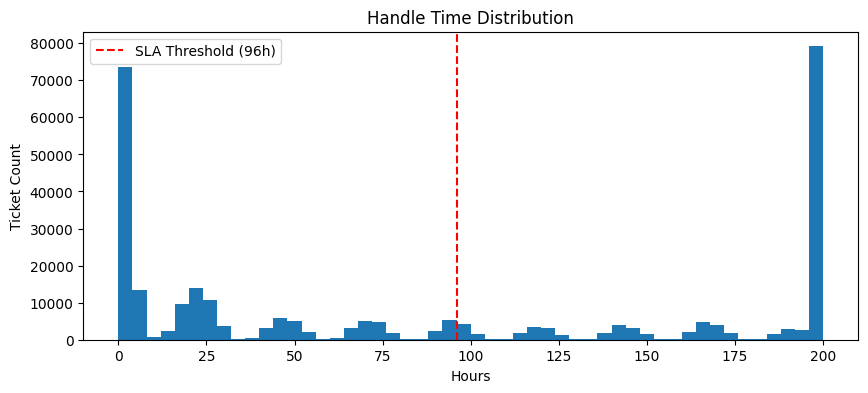

In [3]:
df['Handle Time (Hours)'].clip(upper=200).hist(bins=50, figsize=(10, 4))
plt.axvline(96, color='red', linestyle='--', label='SLA Threshold (96h)')
plt.title("Handle Time Distribution")
plt.xlabel("Hours")
plt.ylabel("Ticket Count")

plt.legend()
plt.grid()
plt.show()


In [5]:
import joblib
# Extract unique assignment groups from training data
assignment_groups = df['Assignment Group'].unique().tolist()

# Save it alongside the model
joblib.dump(assignment_groups, "assignment_groups.pkl")


['assignment_groups.pkl']

In [6]:
features = [ #the focus only on them here
    'Priority', 'Impact', 'Urgency',
    'Number of Reassignments', 'Assignment Group','Open Time', 'Delayed']

df = df[features].dropna()

# convertting categorical columns to category for better usage 
cat_cols = ['Priority', 'Impact', 'Urgency', 'Assignment Group']
df[cat_cols] = df[cat_cols].astype('category')

# One-hot encode
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)


In [7]:
split_date = '2014-01-01'
train_df = df[df['Open Time'] < split_date]
test_df = df[df['Open Time'] >= split_date]

X_train = train_df.drop(columns=['Open Time', 'Delayed'])
y_train = train_df['Delayed']
X_test = test_df.drop(columns=['Open Time', 'Delayed'])
y_test = test_df['Delayed']

print("Train class counts:\n", y_train.value_counts())
print("Test class counts:\n", y_test.value_counts())


Train class counts:
 Delayed
0    84377
1    79912
Name: count, dtype: int64
Test class counts:
 Delayed
0    84319
1    46024
Name: count, dtype: int64


In [8]:
tree = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
tree.fit(X_train, y_train)

y_pred_prob = tree.predict_proba(X_test)[:, 1]


In [9]:
from sklearn.metrics import accuracy_score, classification_report

# Predict class labels (0 or 1)
y_pred_class = (y_pred_prob >= 0.5).astype(int) 

#Compute accuracy
accuracy = accuracy_score(y_test, y_pred_class)

print(f"Accuracy: {accuracy:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_class, target_names=['On-time', 'Delayed']))



Accuracy: 0.769

Classification Report:
              precision    recall  f1-score   support

     On-time       0.80      0.86      0.83     84319
     Delayed       0.70      0.60      0.65     46024

    accuracy                           0.77    130343
   macro avg       0.75      0.73      0.74    130343
weighted avg       0.76      0.77      0.76    130343



In [10]:
import joblib
joblib.dump(tree, "tree_model2.pkl")
joblib.dump(list(X_train.columns), "model_features2.pkl")


['model_features2.pkl']

In [11]:
df

,Number of Reassignments,Open Time,Delayed,Priority_2,Priority_3,Priority_4,Priority_5,Impact_2,Impact_3,Impact_4,...,Assignment Group_TEAM0233,Assignment Group_TEAM0234,Assignment Group_TEAM0235,Assignment Group_TEAM0236,Assignment Group_TEAM0237,Assignment Group_TEAM0238,Assignment Group_TEAM0239,Assignment Group_TEAM0240,Assignment Group_TEAM0241,Assignment Group_TEAM9999
0,26.0,2012-02-05 13:32:57,1,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,26.0,2012-02-05 13:32:57,1,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,26.0,2012-02-05 13:32:57,1,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,26.0,2012-02-05 13:32:57,1,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,26.0,2012-02-05 13:32:57,1,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303814,0.0,2014-03-31 15:35:35,0,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
303815,0.0,2014-03-31 15:35:35,0,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
303816,0.0,2014-03-31 17:24:49,0,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
303817,0.0,2014-03-31 17:24:49,0,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


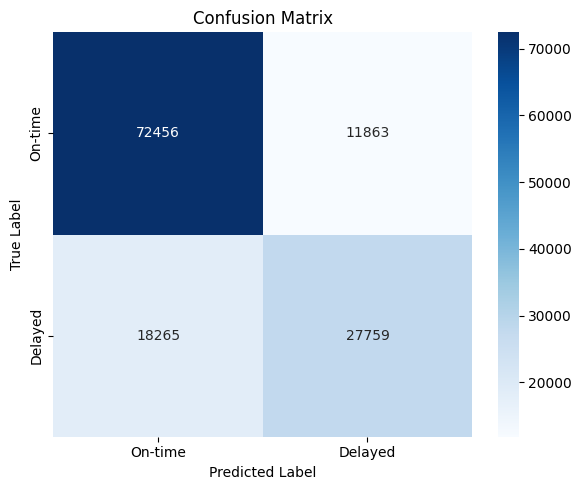

In [12]:
import pandas as pd
import joblib
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load saved data 
tree = joblib.load("./tree_model2.pkl")
model_features = joblib.load("./model_features2.pkl")

# Load and prepare the dataset
df = pd.read_csv("incidentProcess_custom.csv", sep='\t', dayfirst=True)
df.columns = df.columns.str.strip()
df['Open Time'] = pd.to_datetime(df['Open Time'], errors='coerce', dayfirst=True)
df['Resolved Time'] = pd.to_datetime(df['Resolved Time'], errors='coerce', dayfirst=True)
df = df.dropna(subset=['Open Time', 'Resolved Time'])
df['Handle Time (Hours)'] = (df['Resolved Time'] - df['Open Time']).dt.total_seconds() / 3600
df = df[df['Handle Time (Hours)'] >= 0]
df['Delayed'] = (df['Handle Time (Hours)'] > 96).astype(int)

features = ['Priority', 'Impact', 'Urgency', 'Number of Reassignments', 'Assignment Group', 'Open Time', 'Delayed']
df = df[features].dropna()

cat_cols = ['Priority', 'Impact', 'Urgency', 'Assignment Group']
df[cat_cols] = df[cat_cols].astype('category')
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

split_date = '2014-01-01'
train_df = df[df['Open Time'] < split_date]
test_df = df[df['Open Time'] >= split_date]

X_test = test_df.drop(columns=['Open Time', 'Delayed'])
y_test = test_df['Delayed']

# Align test features to model input
for col in model_features:
    if col not in X_test.columns:
        X_test[col] = 0
X_test = X_test[model_features]

# Predict
y_pred_prob = tree.predict_proba(X_test)[:, 1]
y_pred_class = (y_pred_prob >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_class)
labels = ['On-time', 'Delayed']

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [13]:
from flask import Flask, request, render_template_string
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
import joblib



tree = joblib.load("tree_model2.pkl")
model_features = joblib.load("model_features2.pkl")
assignment_groups = joblib.load("assignment_groups.pkl")


# === Flask App ===
app = Flask(__name__)


html_form = """
<!doctype html>
<html lang=\"en\">
<head>
  <meta charset=\"utf-8\">
  <meta name=\"viewport\" content=\"width=device-width, initial-scale=1\">
  <title>SLA Delay Predictor</title>
  <style>
    body { font-family: Arial, sans-serif; margin: 2em; background: #f4f4f4; }
    h2 { color: #333; }
    form { background: #fff; padding: 2em; border-radius: 8px; box-shadow: 0 0 10px rgba(0,0,0,0.1); max-width: 400px; }
    input, select { margin-top: 0.5em; margin-bottom: 1em; width: 100%; padding: 0.5em; font-size: 1em; }
    input[type=\"submit\"] { background: #007BFF; color: white; border: none; border-radius: 4px; cursor: pointer; }
    input[type=\"submit\"]:hover { background: #0056b3; }
    .result { background: #fff; padding: 1em; margin-top: 1em; border-left: 5px solid #007BFF; }
  </style>
</head>
<body>
<h2> SLA Delay Prediction</h2>
<form method=post>
  <label>Priority:</label>
  <input type=number name=Priority value=3 min=1 max=5 required>

  <label>Impact:</label>
  <input type=number name=Impact value=2 min=1 max=5 required>

  <label>Urgency:</label>
  <input type=number name=Urgency value=3 min=1 max=5 required>

  <label>Number of Reassignments:</label>
  <input type=number name=Number_of_Reassignments value=1 min=0 required>

  <label>Assignment Group:</label>
  <select name="Assignment_Group">
    {% for group in assignment_groups %}
      <option value="{{ group }}">{{ group }}</option>
    {% endfor %}
  </select>


  <input type=submit value=Predict>
</form>

{% if prediction %}
<div class=\"result\">
  <h3>Prediction: {{ prediction }}</h3>
  <p>Predicted Delay Risk Score: <strong>{{ prob }}</strong></p>
</div>
{% endif %}
</body>
</html>
"""

# Prediction Route
@app.route("/", methods=["GET", "POST"])
def index():
    prediction = None
    prob = None
    if request.method == "POST":
        input_dict = {
            "Priority": int(request.form['Priority']),
            "Impact": int(request.form['Impact']),
            "Urgency": int(request.form['Urgency']),
            "Number of Reassignments": int(request.form['Number_of_Reassignments']),
            "Assignment Group": request.form['Assignment_Group']
        }
        df_input = pd.DataFrame([input_dict])
        df_input = pd.get_dummies(df_input, columns=['Priority', 'Impact', 'Urgency', 'Assignment Group'], drop_first=True)

        for col in model_features:
            if col not in df_input.columns:
                df_input[col] = 0
        df_input = df_input[model_features]

        prob_val = tree.predict_proba(df_input)[0][1]
        prediction = "⚠️ Likely Delayed" if prob_val > 0.5 else "✅ Likely On-Time"
        prob = f"{prob_val:.2%}"

    return render_template_string(html_form, prediction=prediction, prob=prob, assignment_groups=assignment_groups)


from werkzeug.serving import run_simple
import threading

PORT = 5050 
def run_app():
    run_simple('localhost', PORT, app)

thread = threading.Thread(target=run_app)
thread.start()



 * Running on http://localhost:5050
Press CTRL+C to quit
